# Win rate by time to match and predicted margin

The same campaign currently selected in `survey_experiments.ipynb`. The first chart bets every game and compares CV with holdout by hours before tip-off. The second chart uses fixed minimum predicted margins (in points) at each horizon. Higher rows require a larger margin. A blank heatmap cell has fewer than 30 decided bets; the number under each rate is the decided-bet count. Pushes are excluded from win rate.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Could not find the project root.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training_pipeline.betting import evaluate_betting, outcome_from_predictions
from training_pipeline.reporting import coverage, loaders, theme
from training_pipeline.reporting.discovery import load_runs

# Match the active SOURCES assignment in survey_experiments.ipynb.
SOURCES = ["experiments/early_line_error_window_2_5_2026_09"]
MARGIN_THRESHOLDS = (0.5, 1.0, 1.5, 2.0, 2.5, 3.0)  # points
MIN_DECIDED_BETS = 30

theme.apply_theme()
runs = theme.describe_runs(theme.prepare_runs(
    load_runs(SOURCES, artifacts_root="artifacts/experiments", project_root=PROJECT_ROOT)
))
runs = runs[runs["snapshot_minutes"].notna()].copy()
if runs.empty:
    raise ValueError("No runs with a recorded time to match were found.")
runs["hours_to_match"] = runs["snapshot_minutes"] / 60
runs["variant"] = runs["run_name"].str.contains("decay", case=False, na=False)
runs["time_label"] = runs["hours_to_match"].map(lambda hours: f"{hours:g}h")
runs.loc[runs["variant"], "time_label"] += " decay"
runs = runs.sort_values(["hours_to_match", "variant"]).reset_index(drop=True)

predictions = loaders.load_prediction_cache(runs)
scoreboard = coverage.build_scoreboard(runs, predictions)
overall = runs[["label", "hours_to_match", "variant"]].merge(
    scoreboard[["label", "cv_win_rate", "holdout_win_rate"]], on="label"
)

rows = []
for run in runs.itertuples():
    for source, frame in predictions.get(run.label, {}).items():
        for threshold in MARGIN_THRESHOLDS:
            result = evaluate_betting(
                predicted_edge=frame["predicted_edge"],
                actual_total=outcome_from_predictions(frame),
                line=frame["target_line"],
                selection_score=frame["selection_score"],
                min_edge=threshold,
            )
            rows.append({
                "label": run.label,
                "source": source,
                "threshold": threshold,
                "win_rate": result.win_rate,
                "n_decided": result.n_wins + result.n_losses,
            })
threshold_results = pd.DataFrame(rows)
if threshold_results.empty:
    raise ValueError("No CV or holdout prediction artifacts were found.")
print(f"{len(runs)} runs loaded; {len(threshold_results)} threshold results scored.")


18 runs loaded; 216 threshold results scored.


## Win rate by time to match

Each line uses every prediction, exactly as in the survey's full-volume comparison. The diamond marks the separate time-decay experiment at 6 hours.


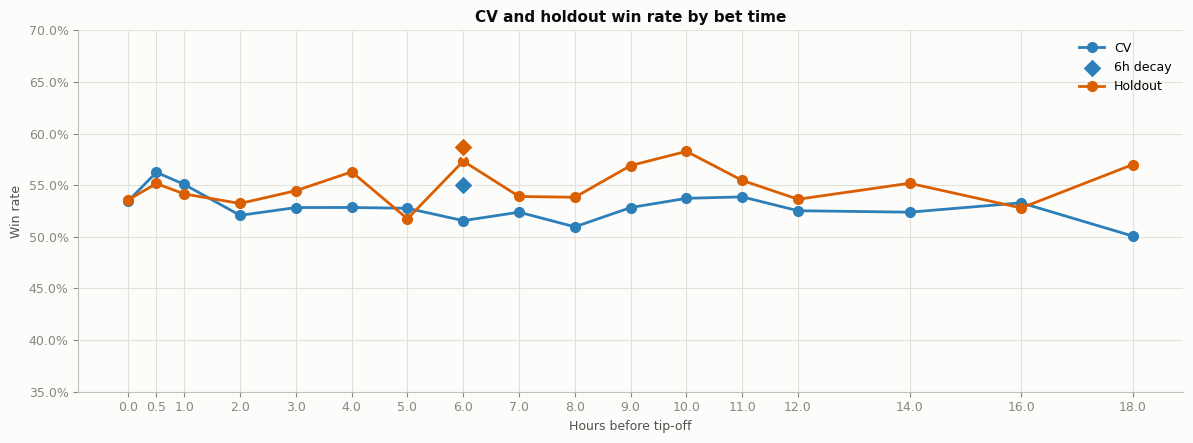

In [2]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for column, name, colour in (
    ("cv_win_rate", "CV", "#2c7fb8"),
    ("holdout_win_rate", "Holdout", "#d95f02"),
):
    standard = overall[~overall["variant"]].sort_values("hours_to_match")
    ax.plot(standard["hours_to_match"], standard[column], marker="o", color=colour, label=name)
    decay = overall[overall["variant"]]
    ax.scatter(decay["hours_to_match"], decay[column], marker="D", s=110,
               color=colour, edgecolor="white", linewidth=1.5, zorder=5,
               label="6h decay" if column == "cv_win_rate" else None)

ax.set(xlabel="Hours before tip-off", ylabel="Win rate", title="CV and holdout win rate by bet time")
ax.set_xticks(sorted(overall["hours_to_match"].unique()))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(coverage.win_rate_limits(
    overall[["cv_win_rate", "holdout_win_rate"]].to_numpy().ravel()
))
ax.legend()
fig.tight_layout()
plt.show()


## Win rate at different minimum margins

Each cutoff keeps bets whose absolute predicted edge is **greater than** that many points. Read upward within a time column to see whether demanding more margin raises win rate. CV and holdout use the same fixed point cutoffs; small samples are hidden rather than displayed as sharp-looking rates.


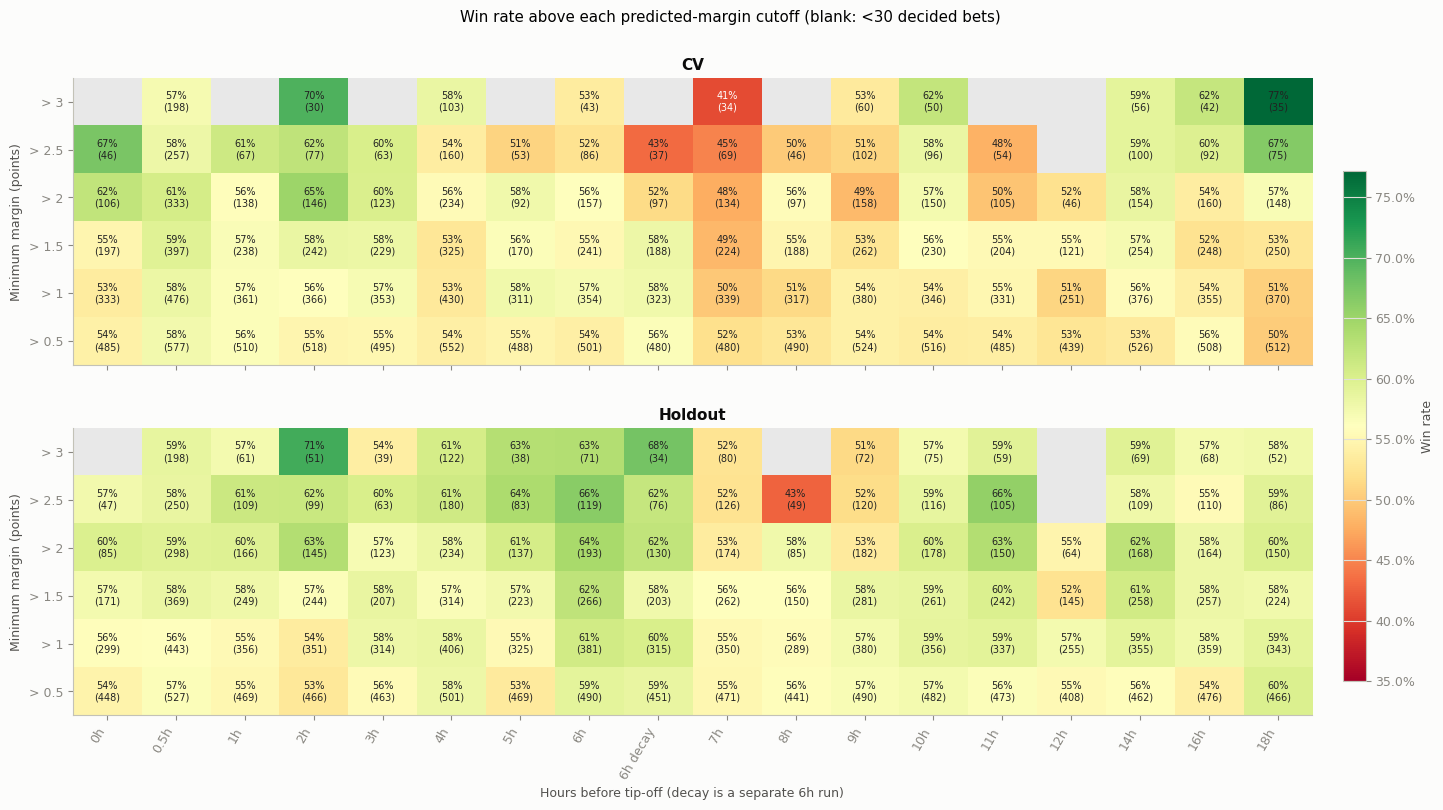

In [3]:
order = runs["label"].tolist()
time_labels = runs["time_label"].tolist()
plot_data = threshold_results.copy()
plot_data.loc[plot_data["n_decided"] < MIN_DECIDED_BETS, "win_rate"] = np.nan

matrices = {}
counts = {}
for source in ("cross-validation", "holdout"):
    side = plot_data[plot_data["source"] == source]
    matrices[source] = side.pivot(index="threshold", columns="label", values="win_rate").reindex(
        index=MARGIN_THRESHOLDS, columns=order
    )
    counts[source] = side.pivot(index="threshold", columns="label", values="n_decided").reindex(
        index=MARGIN_THRESHOLDS, columns=order
    )

visible = np.concatenate([matrix.to_numpy().ravel() for matrix in matrices.values()])
visible = visible[np.isfinite(visible)]
if len(visible) == 0:
    raise ValueError("No threshold has enough decided bets to plot.")
norm = Normalize(vmin=min(0.35, visible.min()), vmax=max(0.70, visible.max()))
cmap = plt.colormaps["RdYlGn"].copy()
cmap.set_bad("#e8e8e8")
fig, axes = plt.subplots(2, 1, figsize=(max(13, len(order) * 0.85), 8.5), sharex=True)
for ax, source, title in zip(
    axes, ("cross-validation", "holdout"), ("CV", "Holdout"), strict=True
):
    matrix = matrices[source]
    image = ax.imshow(np.ma.masked_invalid(matrix.to_numpy(dtype=float)),
                      aspect="auto", origin="lower", cmap=cmap, norm=norm)
    ax.grid(False)
    ax.set_title(title)
    ax.set_ylabel("Minimum margin (points)")
    ax.set_yticks(range(len(MARGIN_THRESHOLDS)), [f"> {t:g}" for t in MARGIN_THRESHOLDS])
    for y, threshold in enumerate(MARGIN_THRESHOLDS):
        for x, label in enumerate(order):
            rate = matrix.loc[threshold, label]
            if pd.notna(rate):
                n = int(counts[source].loc[threshold, label])
                ink = "white" if rate < norm.vmin + 0.18 * (norm.vmax - norm.vmin) else "#222222"
                ax.text(x, y, f"{rate:.0%}\n({n})", ha="center", va="center",
                        fontsize=7, color=ink)

axes[-1].set_xticks(range(len(order)), time_labels, rotation=60, ha="right")
axes[-1].set_xlabel("Hours before tip-off (decay is a separate 6h run)")
fig.subplots_adjust(left=0.07, right=0.88, bottom=0.16, top=0.91, hspace=0.22)
colorbar_ax = fig.add_axes([0.90, 0.20, 0.015, 0.60])
fig.colorbar(image, cax=colorbar_ax, label="Win rate", format=PercentFormatter(1))
fig.suptitle(f"Win rate above each predicted-margin cutoff (blank: <{MIN_DECIDED_BETS} decided bets)", y=0.99)
plt.show()
